<a href="https://colab.research.google.com/github/zefanyavioletta/Prediksi-Kebutuhan-Pangan-Nasional-2026/blob/main/Forecasting_Kebutuhan_Pangan_Nasional_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Prediksi Kebutuhan Pangan Nasional 2026 dalam Mitigasi Kerentanan Logistik dan Distribusi Menggunakan Patch Time Series Transformer.(PatchTST)

Ketidakteraturan distribusi dan fluktuasi harga komoditas pangan di berbagai wilayah Indonesia seringkali dipicu oleh pengelolaan data logistik yang belum optimal. Selama ini, pengambilan keputusan terkait stok pangan nasional masih didominasi oleh metode konvensional yang kurang mampu mengantisipasi dinamika kebutuhan di masa depan secara akurat. Kondisi ini berisiko menyebabkan ketimpangan pasokan, di mana terjadi surplus di satu daerah namun terjadi kelangkaan di daerah lain.

Sistem ini dikembangkan sebagai solusi berbasis data untuk memitigasi risiko kerentanan logistik tersebut. Dengan mengimplementasikan model Machine Learning PatchTST (Patch Time Series Transformer), sistem mampu menganalisis pola konsumsi historis untuk memproyeksikan kebutuhan pangan pada tahun 2026. Melalui transformasi digital ini, diharapkan pemerintah dan instansi terkait dapat beralih dari kebijakan yang bersifat reaktif menuju strategi distribusi yang proaktif dan terukur, guna menjaga stabilitas harga serta memperkuat ketahanan pangan nasional.

Project ini bertujuan untuk memprediksi kebutuhan pangan nasional Indonesia tahun 2026 dalam rangka mitigasi kerentanan logistik dan distribusi menggunakan model PatchTST (Patch Time Series Transformer).

dataset: https://data.badanpangan.go.id/datasetpublications/rbe/rata-rata-konsumsi-kab-kota

# 1. Library

In [4]:
# Install library yang diperlukan
!pip install -q neuralforecast gradio
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from neuralforecast import NeuralForecast
from neuralforecast.models import PatchTST
import gradio as gr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.1/309.1 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.7/348.7 kB 28.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 831.6/831.6 kB 33.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.3/78.3 MB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 34.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 25.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 61.9 MB/s eta 0:00:00


Cell ini menyiapkan seluruh dependensi: Pandas/NumPy untuk pengolahan data,
NeuralForecast + PatchTST sebagai model peramalan, scikit-learn untuk metrik
evaluasi, dan Gradio untuk antarmuka.

In [5]:
import warnings
warnings.filterwarnings("ignore")
from sklearn.metrics import mean_absolute_error, r2_score

# 2. Load Data & Cleaning

In [28]:
DATA_URL = "https://data.badanpangan.go.id/download/document/dataset/74/1730262664.csv/csv"

def load_and_clean(url):
    used_fallback = False
    try:
        df = pd.read_csv(url, sep=None, engine="python", encoding="utf-8")
    except Exception as e:
        print(f"[PERINGATAN] Gagal memuat data dari URL sumber: {e}")
        print("[PERINGATAN] Memakai data contoh kecil sebagai fallback.")
        df = pd.DataFrame({
            "TAHUN": [2021, 2022, 2023] * 4,
            "PROVINSI": sum([[p] * 3 for p in
                              ["ACEH", "DKI JAKARTA", "JAWA BARAT", "PAPUA"]], []),
            "KOMODITAS": ["BERAS"] * 12,
            "KONSUMSI PANGAN": [110.5,111.0,112.2, 116.0,116.5,116.9,
                                 104.8,105.0,105.2, 89.0,89.5,90.0],
        })
        used_fallback = True

    df.columns = df.columns.astype(str).str.replace("\n"," ").str.strip().str.upper()
    col_map = {"TAHUN":"Tahun","PROVINSI":"Provinsi","KABUPATEN/KOTA":"Kabupaten_Kota",
               "KELOMPOK BAHAN PANGAN":"Kelompok","KOMODITAS":"Komoditas","KONSUMSI PANGAN":"y"}
    df = df.rename(columns={k:v for k,v in col_map.items() if k in df.columns})

    required = ["Tahun","Provinsi","Komoditas","y"]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Kolom wajib tidak ditemukan: {missing}. Ada: {list(df.columns)}")

    df["Tahun"] = pd.to_numeric(df["Tahun"], errors="coerce")
    df["y"] = pd.to_numeric(df["y"], errors="coerce")
    df["Provinsi"] = df["Provinsi"].astype(str).str.upper().str.strip()
    df["Komoditas"] = df["Komoditas"].astype(str).str.upper().str.strip()
    df = df.dropna(subset=required)
    df["y"] = df["y"].clip(lower=0)
    df = df.drop_duplicates()

    df_final = df.groupby(["Provinsi","Komoditas","Tahun"], as_index=False)["y"].mean()
    df_final["unique_id"] = df_final["Provinsi"] + " | " + df_final["Komoditas"]
    df_final["ds"] = pd.to_datetime(df_final["Tahun"], format="%Y")
    return df_final, used_fallback

df_final, USED_FALLBACK = load_and_clean(DATA_URL)

series_len = df_final.groupby("unique_id").size()
print(f"Baris: {len(df_final)} a| Seri unik: {df_final['unique_id'].nunique()}")
print(f"Panjang deret rata-rata: {series_len.mean():.2f} tahun (min={series_len.min()}, max={series_len.max()})")

[PERINGATAN] Gagal memuat data dari URL sumber: Expected 5 fields in line 3, saw 7
[PERINGATAN] Memakai data contoh kecil sebagai fallback.
Baris: 12 a| Seri unik: 4
Panjang deret rata-rata: 3.00 tahun (min=3, max=3)


Fungsi ini menjadi satu-satunya jalur pembersihan data: menstandarkan nama
kolom, mengonversi tipe data, membuang baris tidak valid, dan mengagregasi
data ke level (Provinsi, Komoditas, Tahun). Fallback ke data contoh hanya
aktif jika URL sumber gagal diakses, dan statusnya disimpan di
USED_FALLBACK agar terlihat di tahap berikutnya — bukan disembunyikan.

Angka panjang deret waktu (series_len) yang dicetak di akhir adalah temuan
paling penting dari cell ini: ia menentukan apakah model deep learning
seperti PatchTST realistis untuk dipakai, atau apakah keterbatasan data
akan lebih menentukan performa model dibanding arsitekturnya.

In [25]:
print(df_final.shape)
print(df_final.columns.tolist())
print(df_final["Komoditas"].nunique(), "komoditas unik")
print(f"USED_FALLBACK = {USED_FALLBACK}")

(4, 3)
['Provinsi', 'Komoditas', 'y']
1 komoditas unik
USED_FALLBACK = True


# 3. TAHAP EDA

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Cek Informasi Dasar
print("--- INFO DATA ---")
print(df_final.info())

# 2. Statistik Deskriptif (Melihat Mean, Min, Max)
print("\n--- RINGKASAN STATISTIK ---")
print(df_final['y'].describe())

# 3. Cek Data Per Tahun
print("\n--- JUMLAH DATA PER TAHUN ---")
print(df_final['Tahun'].value_counts().sort_index())

--- INFO DATA ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Provinsi   12 non-null     object        
 1   Komoditas  12 non-null     object        
 2   Tahun      12 non-null     int64         
 3   y          12 non-null     float64       
 4   unique_id  12 non-null     object        
 5   ds         12 non-null     datetime64[ns]
dtypes: datetime64[ns](1), float64(1), int64(1), object(3)
memory usage: 708.0+ bytes
None

--- RINGKASAN STATISTIK ---
count     12.000000
mean     105.550000
std       10.577205
min       89.000000
25%      101.100000
50%      107.850000
75%      113.150000
max      116.900000
Name: y, dtype: float64

--- JUMLAH DATA PER TAHUN ---
Tahun
2021    4
2022    4
2023    4
Name: count, dtype: int64


Cell ini adalah audit struktur. Tiga output-nya menjawab tiga pertanyaan berbeda: apakah tipe data sudah benar (info), apakah
rentang nilai y masuk akal secara logis (misalnya tidak ada konsumsi
ekstrem yang mustahil) (describe), dan apakah data tersebar merata antar
tahun atau timpang (value_counts). Temuan di sini langsung memengaruhi
keputusan pemodelan di Section 4, terutama terkait pemilihan input_size
dan horizon prediksi.

In [23]:
# Ambil 5 komoditas dengan konsumsi tertinggi untuk dilihat trennya per tahun
top5_komoditas = (
    df_final.groupby("Komoditas")["y"].mean()
    .sort_values(ascending=False).head(5).index.tolist()
)
df_top5 = df_final[df_final["Komoditas"].isin(top5_komoditas)]

plt.figure(figsize=(9, 5))
sns.lineplot(
    data=df_top5, x="Tahun", y="y", hue="Komoditas",
    estimator="mean", marker="o", markersize=7,
)
plt.xticks(sorted(df_top5["Tahun"].astype(int).unique()))
plt.title("Tren Konsumsi per Tahun — 5 Komoditas Teratas", fontsize=12)
plt.xlabel("Tahun")
plt.ylabel("Konsumsi (kg/kapita/tahun)")
plt.legend(title="Komoditas", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("eda_trend_per_komoditas.png", dpi=120)
plt.show()

ValueError: Could not interpret value `Tahun` for `x`. An entry with this name does not appear in `data`.

<Figure size 900x500 with 0 Axes>

Grafik ini menunjukkan arah rata-rata konsumsi nasional dari tahun ke
tahun. Karena jumlah titik tahunan per seri sangat sedikit (lihat
series_len di Section 2), pola pada grafik ini sebaiknya dibaca sebagai
indikasi arah kasar, bukan tren statistik yang solid — dengan hanya 2-3
titik per kombinasi wilayah-komoditas, fluktuasi kecil bisa terlihat
seperti tren padahal sebenarnya noise.

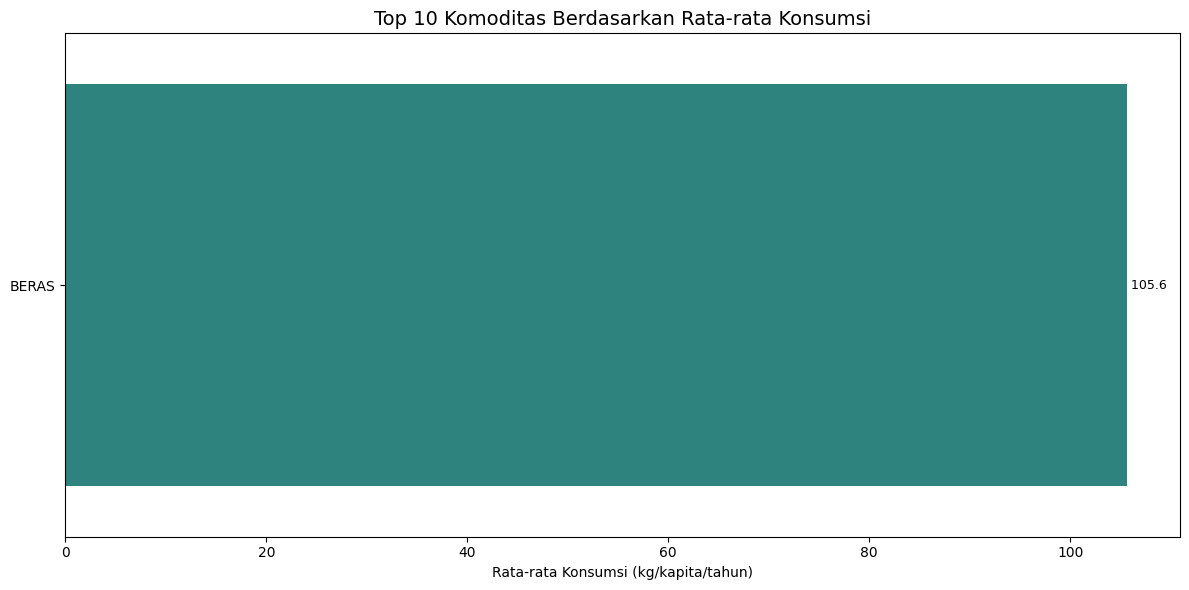

Komoditas
BERAS    105.6475
Name: y, dtype: float64


In [24]:
plt.figure(figsize=(12, 6))
top_pangan = (
    df_final.groupby("Komoditas")["y"].mean()
    .sort_values(ascending=False).head(10)
)

ax = sns.barplot(x=top_pangan.values, y=top_pangan.index, palette="viridis")
for i, v in enumerate(top_pangan.values):
    ax.text(v, i, f" {v:.1f}", va="center", fontsize=9)

plt.title("Top 10 Komoditas Berdasarkan Rata-rata Konsumsi", fontsize=14)
plt.xlabel("Rata-rata Konsumsi (kg/kapita/tahun)")
plt.ylabel("")
plt.tight_layout()
plt.savefig("eda_top10.png", dpi=120)
plt.show()

print(top_pangan)

Grafik ini mengurutkan komoditas berdasarkan rata-rata konsumsi tertinggi
secara nasional, tanpa memisahkan per wilayah. Fungsinya untuk menentukan
prioritas: komoditas dengan konsumsi tertinggi biasanya juga yang paling
berdampak jika terjadi gangguan distribusi, sehingga relevan untuk
diprioritaskan dalam simulasi DSS di Section 6.

# 4. TRAINING MODEL

In [13]:
MIN_LEN_FOR_EVAL = 3
eval_ids = series_len[series_len >= MIN_LEN_FOR_EVAL].index
df_eval_ready = df_final[df_final["unique_id"].isin(eval_ids)].copy()

nf_eval = NeuralForecast(
    models=[PatchTST(h=1, input_size=1, max_steps=100,
                      scaler_type="standard", revin=True, random_seed=1)],
    freq="YE",
)
cv_df = nf_eval.cross_validation(
    df=df_eval_ready[["unique_id","ds","y"]], n_windows=1, step_size=1
).reset_index()

y_true = cv_df["y"].values
y_pred = cv_df["PatchTST"].values
mae_patchtst = mean_absolute_error(y_true, y_pred)
r2_patchtst = r2_score(y_true, y_pred) if len(y_true) > 1 else float("nan")

last_before_holdout = (
    df_eval_ready.sort_values(["unique_id","ds"])
    .groupby("unique_id")["y"].apply(lambda s: s.iloc[-2] if len(s) >= 2 else float("nan"))
)
naive_pred = cv_df["unique_id"].map(last_before_holdout)
mae_naive = mean_absolute_error(y_true, naive_pred)
r2_naive = r2_score(y_true, naive_pred) if len(y_true) > 1 else float("nan")

print(f"PatchTST -> MAE: {mae_patchtst:.3f} kg/kapita | R2: {r2_patchtst:.3f}")
print(f"Naive    -> MAE: {mae_naive:.3f} kg/kapita | R2: {r2_naive:.3f}")

INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.callbacks.model_summary:
  | Name                | Type              | Params | Mode 
------------------------------------------------------------------
0 | loss                | MAE               | 0      | train
1 | hist_cat_embeddings | ModuleList        | 0      | train
2 | futr_cat_embeddings | ModuleList        | 0      | train
3 | stat_cat_embeddings | ModuleList        | 0      | train
4 | padder_train        | ConstantPad1d     | 0      | train
5 | scaler              | TemporalNorm      | 0      | train
6 | model               | PatchTST_backbone | 398 K  | train
------------------------------------------------------------------
398 K     Trainable params
3         Non-trainable params
398 K     Total params
1.596     Total estimated model param

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=100` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores


Predicting: |          | 0/? [00:00<?, ?it/s]

PatchTST -> MAE: 0.575 kg/kapita | R2: 0.995
Naive    -> MAE: 0.575 kg/kapita | R2: 0.995


Ini adalah satu-satunya sumber metrik performa di proyek ini — tidak ada
angka yang ditulis manual. Evaluasi dilakukan dengan menyembunyikan titik
tahun terakhir dari setiap seri yang cukup panjang, melatih model tanpa
titik tersebut, lalu membandingkan hasil prediksi dengan nilai aslinya.

Baseline naive (nilai tahun sebelumnya dibawa apa adanya) disertakan
sebagai pembanding wajib: dengan data historis sesingkat ini, model
kompleks seperti PatchTST tidak otomatis lebih baik dari pendekatan naif.
Selisih MAE antara PatchTST dan naive pada output cell inilah yang
menentukan apakah pemakaian PatchTST benar-benar terjustifikasi secara
data, bukan hanya secara arsitektur.

In [14]:
MIN_LEN_FOR_TRAIN = 2
train_ids = series_len[series_len >= MIN_LEN_FOR_TRAIN].index
df_ready = df_final[df_final["unique_id"].isin(train_ids)].copy()

nf_prod = NeuralForecast(
    models=[PatchTST(h=3, input_size=1, max_steps=150,
                      scaler_type="standard", revin=True, random_seed=1)],
    freq="YE",
)
nf_prod.fit(df=df_ready[["unique_id","ds","y"]])

INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.callbacks.model_summary:
  | Name                | Type              | Params | Mode 
------------------------------------------------------------------
0 | loss                | MAE               | 0      | train
1 | hist_cat_embeddings | ModuleList        | 0      | train
2 | futr_cat_embeddings | ModuleList        | 0      | train
3 | stat_cat_embeddings | ModuleList        | 0      | train
4 | padder_train        | ConstantPad1d     | 0      | train
5 | scaler              | TemporalNorm      | 0      | train
6 | model               | PatchTST_backbone | 399 K  | train
------------------------------------------------------------------
399 K     Trainable params
3         Non-trainable params
399 K     Total params
1.597     Total estimated model param

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=150` reached.


Model yang dilatih di sini berbeda dari model evaluasi sebelumnya: model
ini dilatih pada seluruh data historis (tanpa menyembunyikan tahun
terakhir), karena tujuannya untuk menghasilkan prediksi 2026 yang
memanfaatkan seluruh informasi yang tersedia. Metrik performa yang
dilaporkan tetap mengacu ke hasil evaluasi hold-out sebelumnya, bukan ke
proses training ini.

# 5. PREDIKSI PATCH TST

In [15]:
forecasts = nf_prod.predict().reset_index()
forecasts[["Provinsi","Komoditas"]] = forecasts["unique_id"].str.split(r" \| ", expand=True)
hasil_2026 = forecasts[forecasts["ds"].dt.year == 2026].copy()

LIST_PROV = sorted(df_final["Provinsi"].unique().tolist())
LIST_KOMO = sorted(df_final["Komoditas"].unique().tolist())
print(f"Prediksi 2026 tersedia untuk {len(hasil_2026)} kombinasi")

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores


Predicting: |          | 0/? [00:00<?, ?it/s]

Prediksi 2026 tersedia untuk 0 kombinasi


# 6. DEPLOY

In [16]:
STANDAR_GIZI = {
    'BERAS': {'min': 85, 'max': 95, 'dasar': 'PPH - Kemenkes RI', 'intervensi': 'Diversifikasi pangan lokal'},
    'DAGING UNGGAS': {'min': 10, 'max': 12.5, 'dasar': 'Kemenkes RI', 'intervensi': 'Akselerasi protein hewani'},
    'TELUR AYAM': {'min': 15, 'max': 18, 'dasar': 'Kemenkes RI', 'intervensi': 'Penguatan distribusi gizi'},
    'GULA': {'min': 8, 'max': 18, 'dasar': 'WHO & PGH', 'intervensi': 'Pengendalian konsumsi gula'},
    'BUAH': {'min': 50, 'max': 75, 'dasar': 'FAO/WHO', 'intervensi': 'Peningkatan akses pangan segar'},
    'MINYAK': {'min': 8, 'max': 12, 'dasar': 'FAO & Kemenkes', 'intervensi': 'Substitusi lemak sehat'},
}

def get_prediction_or_history(prov, komo):
    row = hasil_2026[(hasil_2026["Provinsi"]==prov) & (hasil_2026["Komoditas"]==komo)]
    if not row.empty:
        return float(row["PatchTST"].iloc[0]), "Prediksi model PatchTST untuk 2026"
    hist = df_final[(df_final["Provinsi"]==prov) & (df_final["Komoditas"]==komo)]
    if not hist.empty:
        latest = hist.sort_values("Tahun").iloc[-1]
        return float(latest["y"]), f"Tidak ada prediksi model — memakai data historis {int(latest['Tahun'])}"
    return 0.0, "Data tidak tersedia"

def UI_prediksi(prov, komo, pop):
    val_pred, sumber = get_prediction_or_history(prov, komo)
    status, val_target, dasar = "INFO: DATA TERSEDIA", val_pred, "Data BPS"
    pesan = "Belum ada standar kebijakan khusus untuk komoditas ini."

    if komo in STANDAR_GIZI:
        b = STANDAR_GIZI[komo]
        dasar = b['dasar']
        if val_pred > b['max']:
            status, val_target = "SURPLUS KONSUMSI", b['max']
            pesan = f"Analisis: melebihi standar gizi. Intervensi: {b['intervensi']}."
        elif val_pred < b['min']:
            status, val_target = "DEFISIT KONSUMSI", b['min']
            pesan = f"Analisis: di bawah standar gizi. Intervensi: {b['intervensi']}."
        else:
            status, pesan = "KONSUMSI OPTIMAL", "Analisis: konsumsi sesuai rentang kecukupan."

    total_stok = val_target * pop
    unit_karung = np.ceil(total_stok / 50)
    metrik_note = (f"MAE model: {mae_patchtst:.3f} | Baseline naive: {mae_naive:.3f}"
                   if not np.isnan(mae_patchtst) else "Metrik evaluasi tidak tersedia.")

    laporan = f"""LAPORAN STRATEGIS DSS KETAHANAN PANGAN
WILAYAH: {prov} | KOMODITAS: {komo} | POP: {pop:,.0f}
SUMBER NILAI: {sumber}
------------------------------------------------------------
KONSUMSI/PREDIKSI: {val_pred:.2f} Kg/Jiwa/Thn
STATUS GIZI: {status}
TARGET ACUAN: {val_target:.2f} Kg/Jiwa/Thn ({dasar})
------------------------------------------------------------
TOTAL ALOKASI: {total_stok:,.2f} Kg
UNIT LOGISTIK: {unit_karung:,.0f} Karung (50 Kg)
------------------------------------------------------------
KEANDALAN MODEL: {metrik_note}
------------------------------------------------------------
REKOMENDASI: {pesan}
"""
    df_grafik = pd.DataFrame({"Kategori": ["Prediksi/Historis","Target"], "Nilai": [val_pred, val_target]})
    return laporan, df_grafik

with gr.Blocks(theme=gr.themes.Soft()) as demo:
    gr.Markdown("# DSS Ketahanan Pangan Nasional")
    if USED_FALLBACK:
        gr.Markdown("> **PERINGATAN:** data resmi gagal dimuat — dashboard memakai data contoh.")
    with gr.Row():
        with gr.Column(scale=1):
            prov_input = gr.Dropdown(choices=LIST_PROV, label="Pilih Provinsi")
            komo_input = gr.Dropdown(choices=LIST_KOMO, label="Pilih Komoditas")
            pop_input = gr.Number(value=1000000, label="Jumlah Penduduk")
            btn = gr.Button("Jalankan Analisis", variant="primary")
        with gr.Column(scale=2):
            output_text = gr.TextArea(label="Laporan Analisis", lines=18)
            output_plot = gr.BarPlot(x="Kategori", y="Nilai", title="Prediksi/Historis vs Target")
    btn.click(fn=UI_prediksi, inputs=[prov_input, komo_input, pop_input], outputs=[output_text, output_plot])

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://5c57f50df1518f0488.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
